# 51. N-Queens

The n-queens puzzle is the problem of placing n queens on an **n x n** chessboard such that no two queens attack each other.

Given an integer **n**, return **all distinct solutions to the n-queens puzzle**. You may return the answer in any order.

Each solution contains a distinct board configuration of the n-queens' placement, where 'Q' and '.' both indicate a queen and an empty space, respectively.

 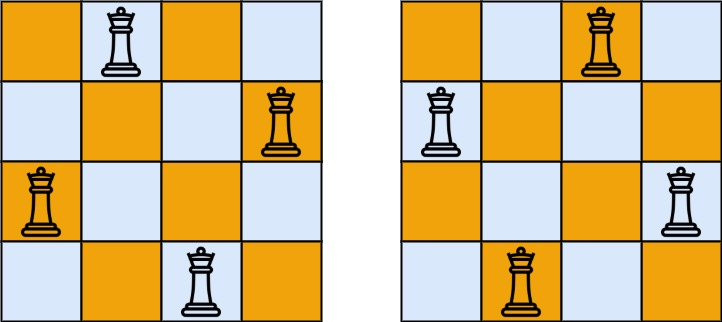

Input: n = 4
Output: [[".Q..","...Q","Q...","..Q."],["..Q.","Q...","...Q",".Q.."]]
Explanation: There exist two distinct solutions to the 4-queens puzzle as shown above

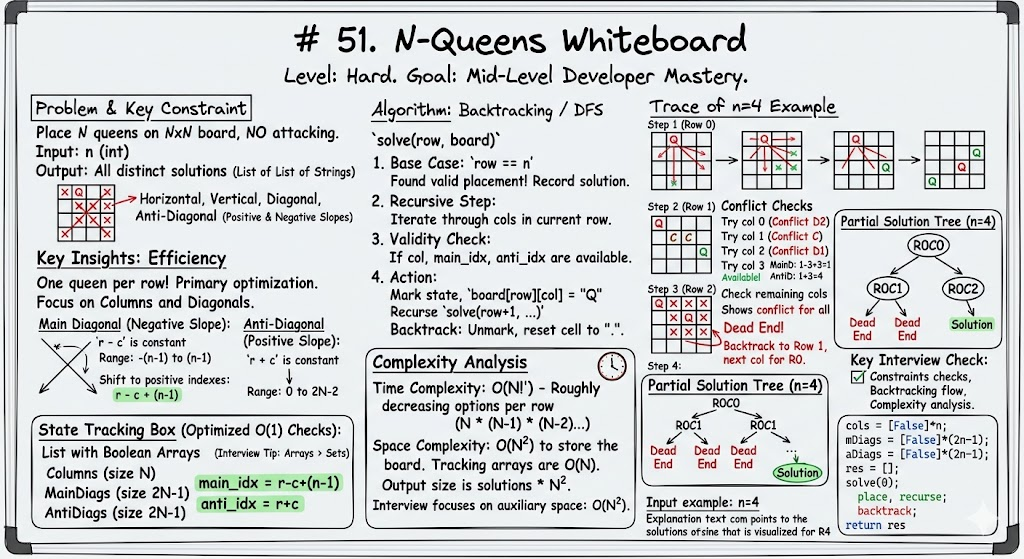

## 🚀 0️⃣ Pattern Recognition

**Type:** Backtracking + Constraint Satisfaction Problem (CSP)

We are NOT traversing a structure.
We are **placing queens row-by-row**, ensuring constraints:

* no same column
* no diagonal conflict

👉 Strategy: **DFS + backtracking with state tracking (columns + diagonals)**

Why this wins:

* Each row has exactly 1 queen
* Branching factor reduces from O(n²) to O(n)
* Constraints allow O(1) checks using sets

---

# 1️⃣ Specification

## 🎯 Core

Place `n` queens on an `n x n` board such that no two queens attack each other, returning all valid configurations.

---

## 🧩 Blueprint

```python id="nq_blueprint"
from typing import List

class Solution:
    def solveNQueens(self, n: int) -> List[List[str]]:
        pass
```

---

## ⚠️ Edge Cases & Traps

1. n = 1 → single solution
2. n = 2 or 3 → no solution
3. diagonal conflicts are the hardest part to reason
4. pruning must happen early (otherwise factorial blow-up)
5. symmetry exists but is not required to optimize

---

# 2️⃣ Plan

## 🧠 Strategy

We place **one queen per row**.

At row `r`, we try placing a queen in each column `c`:

We maintain:

* `cols` → occupied columns
* `diag1` → (r - c)
* `diag2` → (r + c)

Why this works:

* queens attack vertically → cols
* diagonals uniquely identified by constants

---

## 🔍 Visual Trace

For n = 4:

Row 0:

```
Try col 1 → Q
```

State:

```
cols = {1}
diag1 = {0 - 1}
diag2 = {0 + 1}
```

Row 1:

Try positions:

```
(1,0) ❌ diagonal conflict
(1,2) ✔
(1,3) ❌ column free but diagonal conflict may occur later
```

Branching:

```text id="tree"
R0
 ├─ C0
 ├─ C1
 ├─ C2
 └─ C3
     ↓ prune invalid diagonals early
```

---

# 4️⃣ Complexity

## ⏱ Time Complexity

Worst case:

[
O(n!)
]

Why:

* row-by-row placement
* pruning reduces branches significantly but worst-case remains factorial

---

## 🧠 Space Complexity

[
O(n^2 + n)
]

* board: O(n²)
* recursion stack: O(n)
* sets: O(n)

---

# 5️⃣ Refinement

## 🧩 Optimization ideas

* bitmask instead of sets → O(1) faster constants
* symmetry pruning (half board)
* iterative deepening not needed

---

## Naming improvements

* `cols` → `used_columns`
* `diag1` → `diag_r_minus_c`
* `diag2` → `diag_r_plus_c`


---

# 🧠 Final Insight (VERY IMPORTANT)

N-Queens is NOT:

> “placing pieces on a grid”

It is:

> **row-by-row constraint assignment problem**
---


In [ ]:
from typing import List

class Solution:
    def solveNQueens(self, n: int) -> List[List[str]]:
        results = []

        columns = set() # c == c
        diag_main = set()  # r - c
        diag_sec = set()  # r + c

        board = [["."] * n for _ in range(n)]

        def backtrack(r: int):
            # Base case: all rows filled
            if r == n:
                results.append(["".join(row) for row in board])
                return

            for col in range(n):

                # Constraint check (O(1))
                if col in columns or (r - col) in diag_main or (r + col) in diag_sec:
                    continue

                # Place queen
                columns.add(col)
                diag_main.add(r - col)
                diag_sec.add(r + col)
                board[r][col] = "Q"

                # Recurse
                backtrack(r + 1)

                # Undo (backtracking)
                columns.remove(col)
                diag_main.remove(r - col)
                diag_sec.remove(r + col)
                board[r][col] = "."

        backtrack(0)

        return results